In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
clip_scores = pd.read_csv('Art-Protection/eval/outputs/inference_time/clip_scores.csv')
eval_results = pd.read_csv('Art-Protection/eval/outputs/inference_time/inference_eval_results.csv')

# Calculate mean clip scores per condition
mean_clip_scores = clip_scores.drop(columns=['image']).mean()
print(mean_clip_scores)

pg_only             0.644311
glaze+pg_default    0.631601
glaze+pg_high       0.640116
glaze+pg_low        0.627521
mist+pg_default     0.643694
mist+pg_high        0.627723
mist+pg_low         0.646422
pg+glaze_default    0.686047
pg+glaze_high       0.683074
pg+glaze_low        0.675290
pg+mist_default     0.640013
pg+mist_high        0.613416
pg+mist_low         0.646569
dtype: float64


In [3]:
plot_df = eval_results.copy()

# Add a column for order
def get_order(cond):
    if cond == 'pg_only': return 'PG Only'
    if cond.startswith('glaze+pg'): return 'Glaze then PG'
    if cond.startswith('mist+pg'): return 'Mist then PG'
    if cond.startswith('pg+glaze'): return 'PG then Glaze'
    if cond.startswith('pg+mist'): return 'PG then Mist'
    return 'Other'

def get_intensity(cond):
    if 'high' in cond: return 'High'
    if 'low' in cond: return 'Low'
    if 'default' in cond: return 'Default'
    return 'Baseline'

plot_df['order'] = plot_df['condition'].apply(get_order)
plot_df['intensity'] = plot_df['condition'].apply(get_intensity)

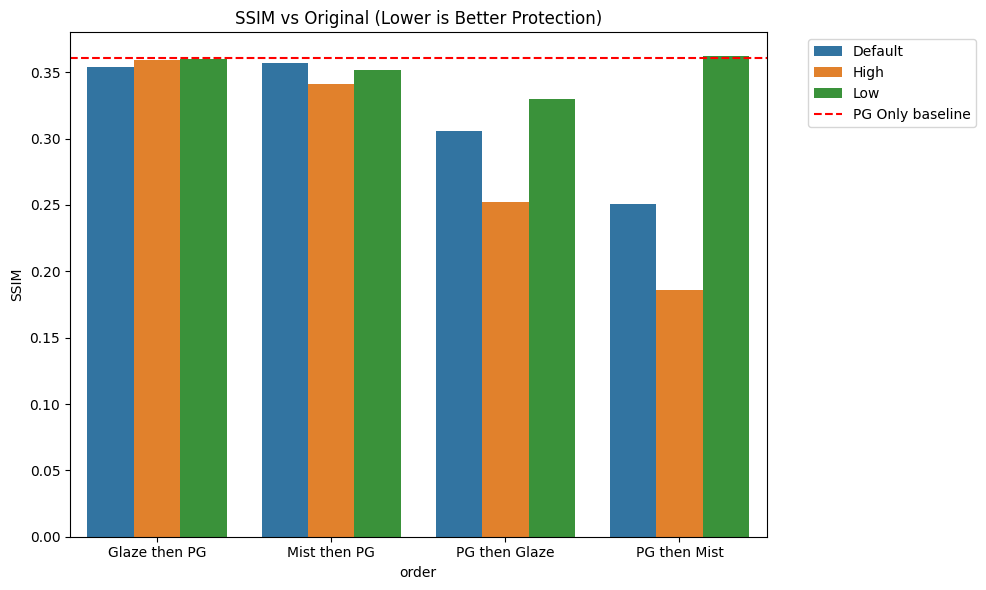

In [4]:
# Plot 1: SSIM vs Original by Order and Intensity
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df[plot_df['order'] != 'PG Only'], x='order', y='ssim_vs_orig', hue='intensity', order=['Glaze then PG', 'Mist then PG', 'PG then Glaze', 'PG then Mist'])
plt.axhline(eval_results[eval_results['condition'] == 'pg_only']['ssim_vs_orig'].values[0], color='r', linestyle='--', label='PG Only baseline')
plt.title('SSIM vs Original (Lower is Better Protection)')
plt.ylabel('SSIM')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('ssim_comparison.png')

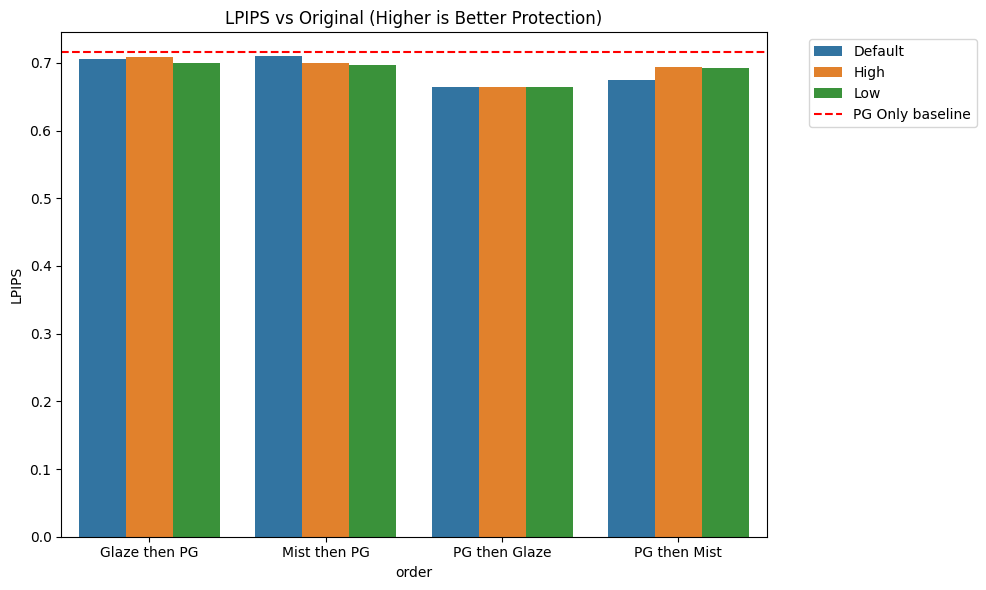

In [5]:
# Plot 2: LPIPS vs Original by Order and Intensity
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df[plot_df['order'] != 'PG Only'], x='order', y='lpips_vs_orig', hue='intensity', order=['Glaze then PG', 'Mist then PG', 'PG then Glaze', 'PG then Mist'])
plt.axhline(eval_results[eval_results['condition'] == 'pg_only']['lpips_vs_orig'].values[0], color='r', linestyle='--', label='PG Only baseline')
plt.title('LPIPS vs Original (Higher is Better Protection)')
plt.ylabel('LPIPS')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('lpips_comparison.png')

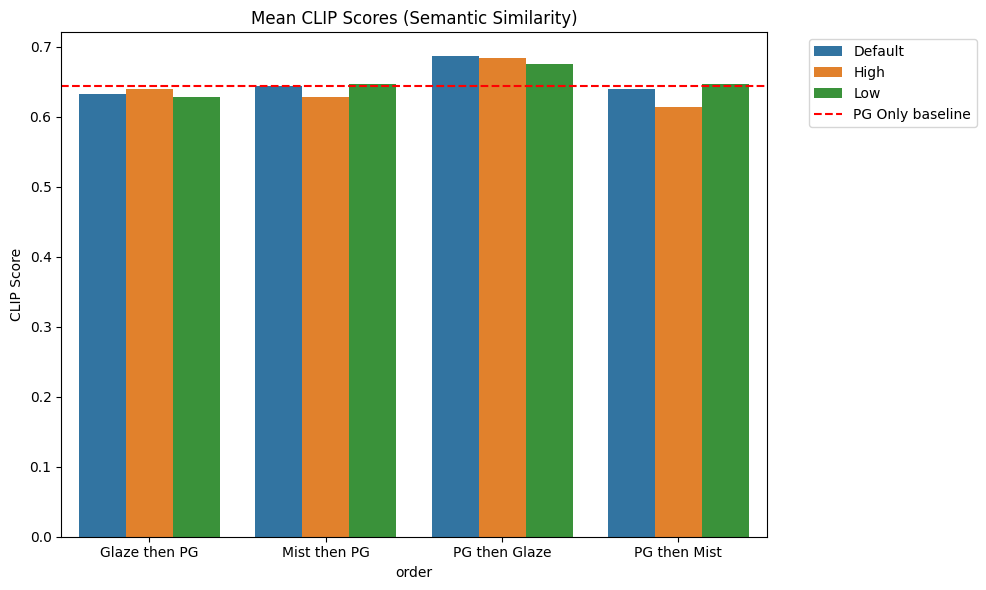

In [6]:
# clip
mean_clip_df = mean_clip_scores.reset_index()
mean_clip_df.columns = ['condition', 'mean_clip_score']
mean_clip_df['order'] = mean_clip_df['condition'].apply(get_order)
mean_clip_df['intensity'] = mean_clip_df['condition'].apply(get_intensity)

plt.figure(figsize=(10, 6))
sns.barplot(data=mean_clip_df[mean_clip_df['order'] != 'PG Only'], x='order', y='mean_clip_score', hue='intensity', order=['Glaze then PG', 'Mist then PG', 'PG then Glaze', 'PG then Mist'])
plt.axhline(mean_clip_scores['pg_only'], color='r', linestyle='--', label='PG Only baseline')
plt.title('Mean CLIP Scores (Semantic Similarity)')
plt.ylabel('CLIP Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('clip_comparison.png')